In [3]:
import pandas as pd

df = pd.read_csv('/content/dataset_limpio_etl.csv')

In [4]:
display(df.head())

,tipo_vivienda,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,aislamiento,eficiencia_construccion,paneles_solares,cantidad_personas,trabajo_remoto,...,electrodomesticos_eficientes,factor_estacional,temperatura_media,consumo_kwh,uso_horario_pico,horas_alto_consumo,tarifa_kwh,costo_estimado,energy_efficiency_score,categoria
0,Departamento,90.1,2,2,29.0,Poor,B,False,2,False,...,74.2,Otoño,22.9,173.68,True,17,0.75,130.2600,41.5,Moderate
1,Departamento,88.3,1,1,37.0,Good,C,False,3,False,...,73.6,Verano,26.9,583.18,True,16,0.75,437.3850,41.5,Moderate
2,Pequeño Comercio,177.7,6,3,26.0,Excellent,C,False,7,False,...,66.2,Primavera,20.7,494.45,True,19,0.75,370.8375,56.6,Efficient
3,Casa,138.6,4,2,5.0,Good,A,True,1,True,...,71.4,Otoño,19.3,109.56,True,20,0.75,82.1700,83.6,Efficient
4,Departamento,57.7,1,1,16.0,Good,B,False,1,True,...,75.4,Invierno,7.9,380.47,True,18,0.75,285.3525,39.8,Moderate


## 1. Limpieza y Normalización de Datos

Prepararemos el set de características `X` eliminando variables circulares y escalaremos los valores numéricos al rango [0, 1].

In [35]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Definir el target
target = 'energy_efficiency_score'

# 1. Seleccionar características
# Usamos X_habitos como base, que ya tiene One-Hot Encoding
X_final = X_habitos.copy()
y_final = df[target]

# 2. Identificar columnas que realmente necesitan escalado (valor máximo > 1)
columnas_numericas = X_final.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Excluimos booleanas y dummies (que están en [0,1])
columnas_a_escalar = [c for c in columnas_numericas if c not in boolean_cols and X_final[c].max() > 1]

# 3. Aplicar Escalado solo si hay columnas detectadas
if columnas_a_escalar:
    scaler_final = MinMaxScaler()
    X_final[columnas_a_escalar] = scaler_final.fit_transform(X_final[columnas_a_escalar])
    print(f"Variables normalizadas en este paso: {columnas_a_escalar}")
else:
    print("Las variables ya se encuentran en la escala [0, 1]. No se requiere normalización adicional.")

display(X_final.head())

Las variables ya se encuentran en la escala [0, 1]. No se requiere normalización adicional.


,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,aislamiento,eficiencia_construccion,paneles_solares,cantidad_personas,trabajo_remoto,horas_en_casa,...,tipo_vivienda_Departamento,tipo_vivienda_Pequeño Comercio,tipo_calefaccion_Gas,tipo_calefaccion_Losa Radiante,tipo_calefaccion_Ninguna,tipo_iluminacion_LED,tipo_iluminacion_Mixta,factor_estacional_Otoño,factor_estacional_Primavera,factor_estacional_Verano
0,0.052538,0.142857,0.25,0.367089,0.0,0.5,False,0.142857,False,0.00000,...,True,False,False,False,False,False,True,True,False,False
1,0.050964,0.000000,0.00,0.468354,0.5,0.0,False,0.285714,False,0.42500,...,True,False,True,False,False,False,False,False,False,True
2,0.129115,0.714286,0.50,0.329114,1.0,0.0,False,0.857143,False,0.00000,...,False,True,False,False,False,False,True,False,True,False
3,0.094935,0.428571,0.25,0.063291,0.5,1.0,True,0.000000,True,0.60000,...,False,False,False,False,False,True,False,True,False,False
4,0.024215,0.000000,0.00,0.202532,0.5,0.5,False,0.000000,True,0.36875,...,True,False,False,False,False,True,False,False,False,False


## 2. Partición de Datos (50/30/20) y Entrenamiento

Con los datos normalizados, dividimos el set y entrenamos el `RandomForestRegressor`.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# División
X_temp, X_test_f, y_temp, y_test_f = train_test_split(X_final, y_final, test_size=0.20, random_state=42)
X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_temp, y_temp, test_size=0.375, random_state=42)

# Entrenamiento
modelo_final_reg = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_final_reg.fit(X_train_f, y_train_f)

# Evaluación
preds_test = modelo_final_reg.predict(X_test_f)
print(f"R² Score Final: {r2_score(y_test_f, preds_test):.4f}")
print(f"MAE Final: {mean_absolute_error(y_test_f, preds_test):.4f}")

R² Score Final: 0.7506
MAE Final: 0.0834


## 3. Análisis Final de Importancia de Variables

Con el modelo de regresión final normalizado y entrenado, visualizamos los factores que tienen mayor peso en el cálculo del score de eficiencia energética.

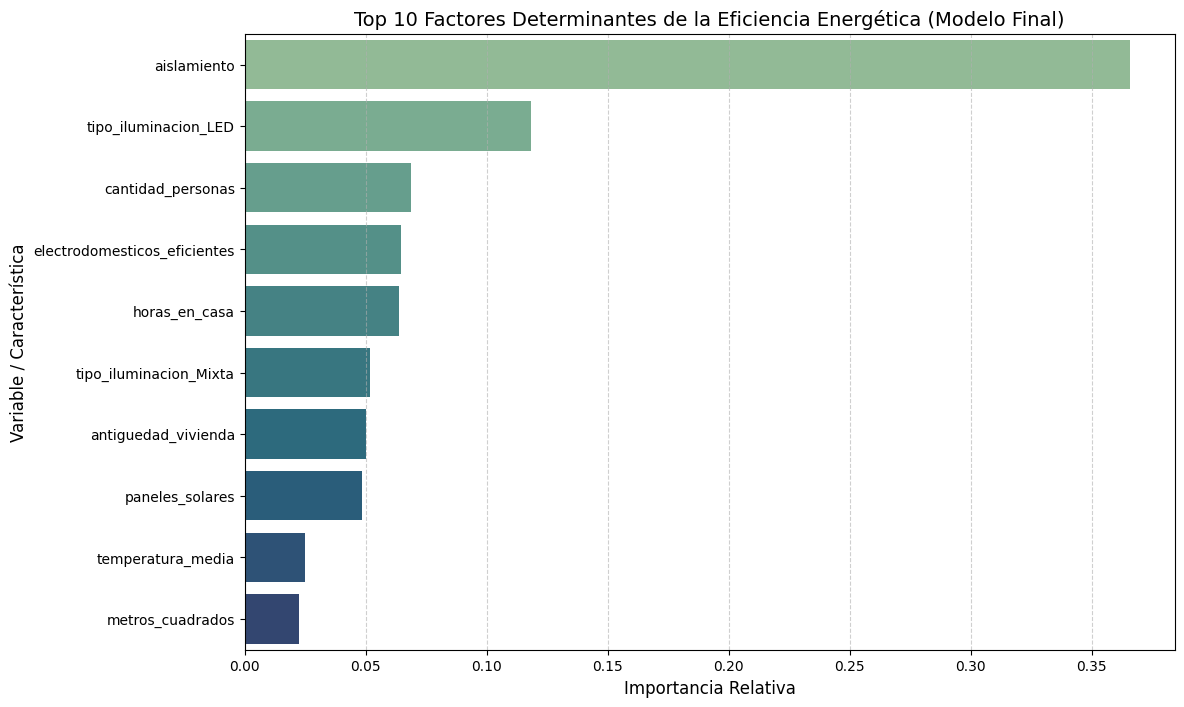

Factores clave identificados:
1. aislamiento: 0.3659
2. tipo_iluminacion_LED: 0.1184
3. cantidad_personas: 0.0687
4. electrodomesticos_eficientes: 0.0645
5. horas_en_casa: 0.0639


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obtener importancia de las variables del modelo final
importancias_final = pd.Series(modelo_final_reg.feature_importances_, index=X_final.columns).sort_values(ascending=False)

# Visualización
plt.figure(figsize=(12, 8))
sns.barplot(x=importancias_final.head(10).values, y=importancias_final.head(10).index, palette='crest', hue=importancias_final.head(10).index, legend=False)
plt.title('Top 10 Factores Determinantes de la Eficiencia Energética (Modelo Final)', fontsize=14)
plt.xlabel('Importancia Relativa', fontsize=12)
plt.ylabel('Variable / Característica', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print("Factores clave identificados:")
for i, (col, val) in enumerate(importancias_final.head(5).items()):
    print(f"{i+1}. {col}: {val:.4f}")

### Inyección de Datos Externos para Prueba

Probaremos el modelo final (`modelo_final_reg`) con un nuevo perfil de vivienda. Esta vez simularemos una casa con aislamiento moderado ('Good') y hábitos de consumo medio.

In [38]:
# Definimos un nuevo caso externo
nueva_vivienda_test = {
    'tipo_vivienda': 'Departamento',
    'metros_cuadrados': 85.0,
    'habitaciones': 2,
    'baños': 1,
    'antiguedad_vivienda': 15.0,
    'aislamiento': 'Good',
    'eficiencia_construccion': 'B',
    'paneles_solares': False,
    'cantidad_personas': 2,
    'trabajo_remoto': False,
    'horas_en_casa': 8.0,
    'ingreso_mensual': 2800.0,
    'aires_acondicionados': 1,
    'heladeras': 1,
    'televisores': 1,
    'computadoras': 1,
    'lavadoras': 1,
    'secadoras': 0,
    'cantidad_equipos': 5,
    'calefaccion': True,
    'tipo_calefaccion': 'Gas',
    'tipo_iluminacion': 'Mixta',
    'electrodomesticos_eficientes': 3.0,
    'factor_estacional': 'Otoño',
    'temperatura_media': 18.0,
    'uso_horario_pico': True,
    'horas_alto_consumo': 4
}

# Ejecutar la predicción usando las columnas de entrenamiento final
try:
    score_predicho = predecir_eficiencia_final(
        nueva_vivienda_test,
        modelo_final_reg,
        X_final.columns.tolist(),
        df_raw
    )

    print(f"--- RESULTADO DE LA PRUEBA EXTERNA ---")
    print(f"Energy Efficiency Score Predicho: {score_predicho:.4f}")

    if score_predicho > 0.6:
        print("Estado: Eficiente")
    elif score_predicho > 0.35:
        print("Estado: Moderado")
    else:
        print("Estado: Ineficiente")
except NameError:
    print("Error: Asegúrate de haber ejecutado la celda que contiene la definición de 'predecir_eficiencia_final'.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

--- RESULTADO DE LA PRUEBA EXTERNA ---
Energy Efficiency Score Predicho: 0.4524
Estado: Moderado


## 4. Clasificación con Regresión Logística

En esta sección, utilizaremos las mismas variables independientes para predecir la categoría de eficiencia energética (`y_multi`).

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---
Accuracy: 0.7450

Reporte de Clasificación:
              precision    recall  f1-score   support

 Ineficiente       0.76      0.71      0.74       497
    Moderado       0.70      0.76      0.73       900
   Eficiente       0.80      0.75      0.78       603

    accuracy                           0.74      2000
   macro avg       0.76      0.74      0.75      2000
weighted avg       0.75      0.74      0.75      2000



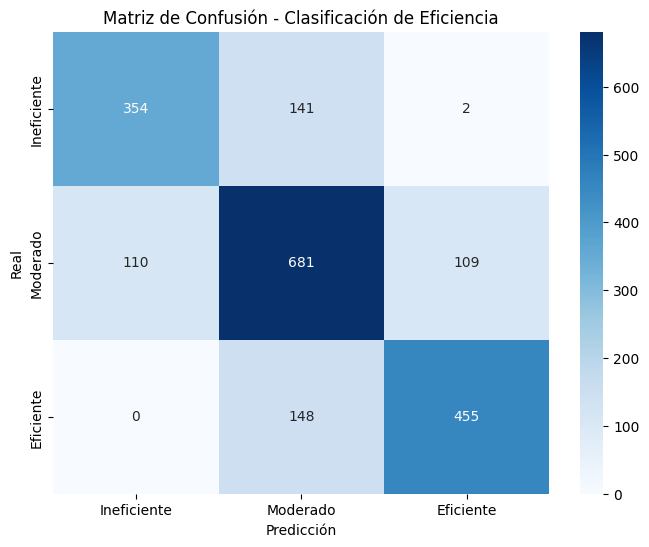

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparar los datos para clasificación
# y_multi contiene las categorías [0, 1, 2]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_final, y_multi, test_size=0.20, random_state=42)

# 2. Entrenar el modelo de Regresión Logística
# Usamos multi_class='multinomial' y aumentamos max_iter para asegurar convergencia
modelo_logistico = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_c, y_train_c)

# 3. Predicciones
y_pred_log = modelo_logistico.predict(X_test_c)

# 4. Evaluación
print("--- EVALUACIÓN REGRESIÓN LOGÍSTICA ---")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_log):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_c, y_pred_log, target_names=['Ineficiente', 'Moderado', 'Eficiente']))

# Visualizar Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_c, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ineficiente', 'Moderado', 'Eficiente'], yticklabels=['Ineficiente', 'Moderado', 'Eficiente'])
plt.title('Matriz de Confusión - Clasificación de Eficiencia')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

### 4.1 Interpretación de Coeficientes

Analizaremos qué variables influyen más en la probabilidad de que una vivienda sea clasificada como 'Ineficiente' o 'Eficiente'.

/tmp/ipykernel_1568/2764658038.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_eficiente.values, y=coef_eficiente.index, palette='viridis')


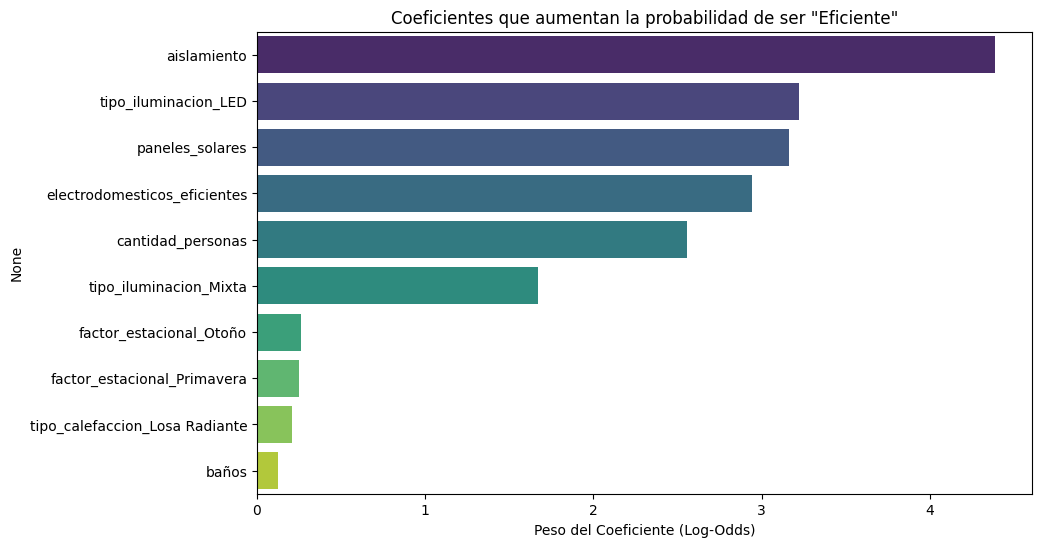

/tmp/ipykernel_1568/2764658038.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_ineficiente.values, y=coef_ineficiente.index, palette='magma')


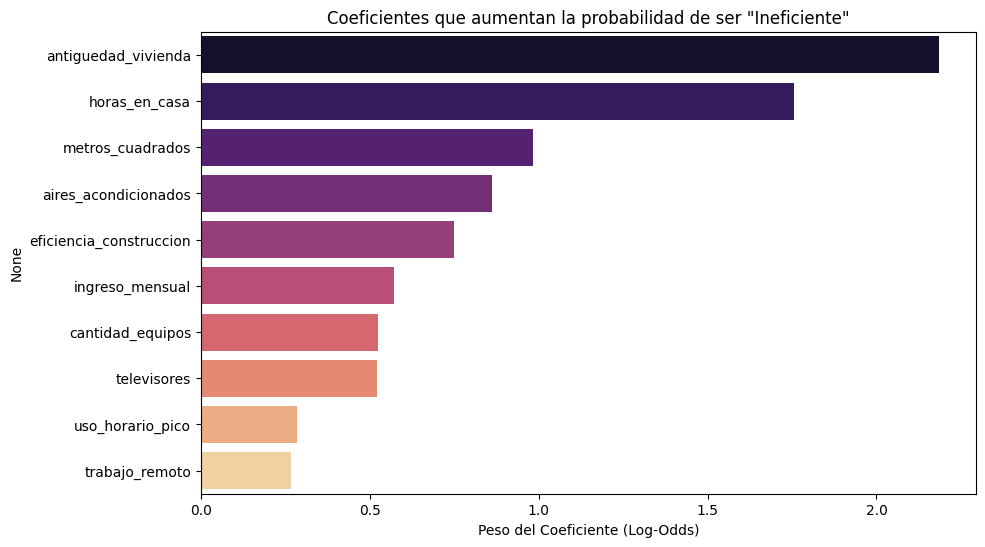

In [40]:
import pandas as pd
import numpy as np

# Extraer coeficientes del modelo
# modelo_logistico.coef_ tiene forma (n_clases, n_features)
coeficientes = pd.DataFrame(
    modelo_logistico.coef_,
    columns=X_final.columns,
    index=['Ineficiente', 'Moderado', 'Eficiente']
)

# Visualizar los 10 coeficientes más influyentes para 'Eficiente'
plt.figure(figsize=(10, 6))
coef_eficiente = coeficientes.loc['Eficiente'].sort_values(ascending=False).head(10)
sns.barplot(x=coef_eficiente.values, y=coef_eficiente.index, palette='viridis')
plt.title('Coeficientes que aumentan la probabilidad de ser "Eficiente"')
plt.xlabel('Peso del Coeficiente (Log-Odds)')
plt.show()

# Visualizar los 10 coeficientes más influyentes para 'Ineficiente'
plt.figure(figsize=(10, 6))
coef_ineficiente = coeficientes.loc['Ineficiente'].sort_values(ascending=False).head(10)
sns.barplot(x=coef_ineficiente.values, y=coef_ineficiente.index, palette='magma')
plt.title('Coeficientes que aumentan la probabilidad de ser "Ineficiente"')
plt.xlabel('Peso del Coeficiente (Log-Odds)')
plt.show()

### 4.2 Importancia de Variables por Categoría (Detalle Comparativo)

A continuación, comparamos cómo influyen las variables en las tres categorías simultáneamente para identificar patrones distintivos.

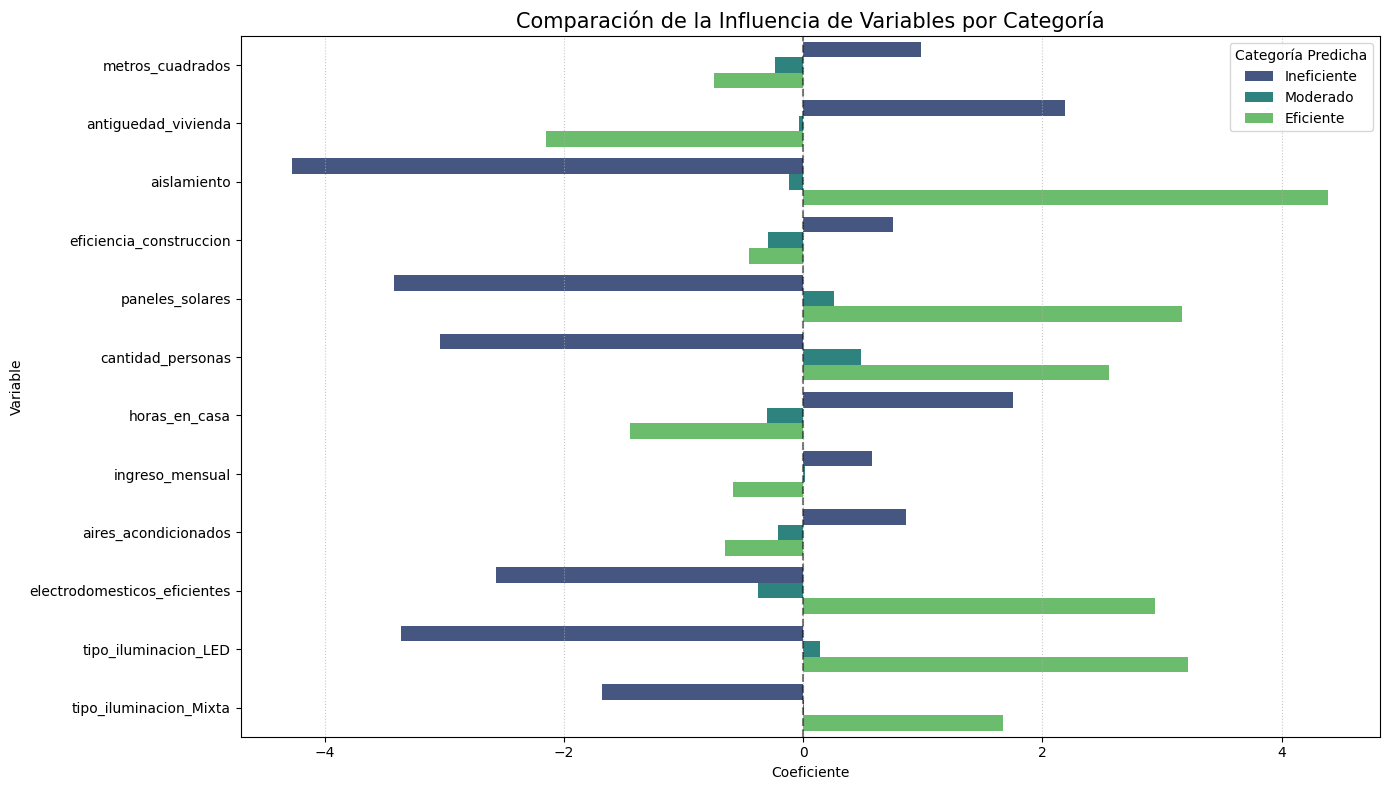

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-estructuramos los coeficientes para graficar con Seaborn
df_coefs_melt = coeficientes.reset_index().rename(columns={'index': 'Categoria'}).melt(id_vars='Categoria', var_name='Variable', value_name='Coeficiente')

# Seleccionamos las variables con mayor impacto absoluto promedio para simplificar el gráfico
top_vars = df_coefs_melt.groupby('Variable')['Coeficiente'].apply(lambda x: x.abs().max()).sort_values(ascending=False).head(12).index
df_plot = df_coefs_melt[df_coefs_melt['Variable'].isin(top_vars)]

plt.figure(figsize=(14, 8))
sns.barplot(data=df_plot, x='Coeficiente', y='Variable', hue='Categoria', palette='viridis')
plt.title('Comparación de la Influencia de Variables por Categoría', fontsize=15)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.legend(title='Categoría Predicha')
plt.tight_layout()
plt.show()

In [42]:
print(f"El modelo utiliza un total de {len(X_final.columns)} características.")
print("\nLista completa de características usadas para el entrenamiento:")
for i, col in enumerate(X_final.columns.tolist(), 1):
    print(f"{i}. {col}")

El modelo utiliza un total de 33 características.

Lista completa de características usadas para el entrenamiento:
1. metros_cuadrados
2. habitaciones
3. baños
4. antiguedad_vivienda
5. aislamiento
6. eficiencia_construccion
7. paneles_solares
8. cantidad_personas
9. trabajo_remoto
10. horas_en_casa
11. ingreso_mensual
12. aires_acondicionados
13. heladeras
14. televisores
15. computadoras
16. lavadoras
17. secadoras
18. cantidad_equipos
19. calefaccion
20. electrodomesticos_eficientes
21. temperatura_media
22. uso_horario_pico
23. horas_alto_consumo
24. tipo_vivienda_Departamento
25. tipo_vivienda_Pequeño Comercio
26. tipo_calefaccion_Gas
27. tipo_calefaccion_Losa Radiante
28. tipo_calefaccion_Ninguna
29. tipo_iluminacion_LED
30. tipo_iluminacion_Mixta
31. factor_estacional_Otoño
32. factor_estacional_Primavera
33. factor_estacional_Verano


In [45]:
import pandas as pd

# Exportar el DataFrame X_final a un archivo CSV
file_path = '/content/dataset_entrenamiento_LR.csv'
X_final.to_csv(file_path, index=False)

print(f"El dataset de entrenamiento LR: {file_path}")

El dataset de entrenamiento LR: /content/dataset_entrenamiento_LR.csv


In [46]:
import pickle

# Guardar el modelo entrenado en un archivo .pkl
model_filename = '/content/modelo_logistico_eficiencia.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(modelo_logistico, file)

print(f"Modelo exportado exitosamente en: {model_filename}")

Modelo exportado exitosamente en: /content/modelo_logistico_eficiencia.pkl


### Resumen Técnico del Modelo Logístico

* **Tipo:** Regresión Logística Multinomial.
* **Variables de entrada:** 33 (incluyendo dummies de tipo de vivienda, iluminación y estacionalidad).
* **Salida:** Clasificación en 3 niveles (0: Ineficiente, 1: Moderado, 2: Eficiente).
* **Interpretabilidad:** Alta. Los coeficientes positivos indican factores que impulsan la pertenencia a una clase, mientras que los negativos actúan como frenos o factores de riesgo para esa categoría específica.